In [ ]:
# ============================================================
# NOTEBOOK 01 - CONVERTIDOR BOOST
# Grado de Electrónica - Electrónica de Potencia
# Septiembre/2026 (c)
#
# Objetivos:
#   1. Analizar el convertidor Boost en CCM
#   2. Relacionar las corrientes del inductor y del condensador
#   3. Obtener las expresiones de Vout, Iout y los rizados
#   4. Comparar teoría, simulación numérica en Python y ngspice
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import os

# Configuración de gráficos
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

# **El convertidor Boost**

Un **convertidor Boost** es un dispositivo electrónico que permite obtener una tensión continua de salida mayor que la tensión continua de entrada, $V_{out}=\frac{V_{in}}{1-D},$ donde $D$ es el ciclo de trabajo (*duty cycle*). El ciclo de trabajo se define como $D=\frac{T_{ON}}{T},$ donde $T$ es el periodo de conmutación, $T_{ON}=DT$ y $T_{OFF}=(1-D)T$ son los intervalos durante los cuales el interruptor permanece cerrado ($ON$) y abierto ($OFF$), respectivamente. Los elementos fundamentales del **convertidor Boost** son:

* Interruptor. Conecta el nodo del inductor a masa durante el intervalo ON.

* Diodo. Permite transferir energía desde el inductor hacia la salida durante el intervalo OFF.

* Inductor. Almacena energía y se opone a cambios bruscos de corriente,
$v_L=L\frac{di_L}{dt}$.

* Condensador. Almacena energía y se opone a cambios bruscos de tensión,
$i_C=C\frac{dv_C}{dt}$, suavizando la tensión de salida.

* Resistor. Representa la carga.


* Cuando el interruptor está **cerrado (ON)**, el extremo derecho del inductor queda conectado a masa. La tensión aplicada al inductor es $v_L=V_{in}$ y como $v_L=L\frac{di_L}{dt}$ tenemos:

$$
\boxed{
\frac{di_L}{dt}
=
\frac{V_{in}}{L}
}
$$

> Durante ON, la corriente del inductor aumenta linealmente.

* Cuando el interruptor está **abierto (OFF)**, el inductor entrega energía a la salida a través del diodo. La tensión sobre el inductor es $v_L=V_{in}-V_{out}$ y por tanto

$$
\boxed{
\frac{di_L}{dt}
=
\frac{V_{in}-V_{out}}{L}
}
$$

> En un Boost ideal $V_{out}>V_{in}$, por lo que $\frac{di_L}{dt}<0$: la corriente del inductor disminuye linealmente.


# Corriente en el inductor

En **PSS**, la corriente del inductor comienza cada periodo con el mismo valor con el que terminó el periodo anterior, por lo que $\Delta i_L=0$ al considerar un periodo completo.

* Durante el intervalo ON:

$$
\Delta i_{L,ON}
=
\frac{V_{in}}{L}DT
$$

* Durante el intervalo OFF:

$$
\Delta i_{L,OFF}
=
\frac{V_{in}-V_{out}}{L}(1-D)T
$$

En régimen estacionario (**PSS**), $\Delta i_{L,ON}+\Delta i_{L,OFF}=0$ por lo que

$$
\frac{V_{in}}{L}DT+
\frac{V_{in}-V_{out}}{L}(1-D)T=0.
$$

Después de simplificar:

$$
\boxed{
V_{out}=\frac{V_{in}}{1-D}
}
$$

El rizado de corriente del inductor es $\Delta i_L=i_{L,max}-i_{L,min},
$ y en CCM se cumple $I_{L,min}>0$. La corriente media del inductor no es igual a la corriente de salida. En **PSS**, la relación de potencia ideal permite escribir $\left\langle V_{in}I_{L} \right\rangle=\left\langle V_{out}I_{out} \right\rangle$ de donde $ \left\langle I_{L} \right\rangle = \frac{I_{out}}{1-D}$


# Corriente del condensador

En el convertidor Boost, el comportamiento de $i_C$ depende directamente del estado del interruptor.

* Durante intervalo **ON**, el diodo está bloqueado y la carga es alimentada por el condensador, $i_C=-I_{out}$


* Durante intervalo **OFF**, el diodo conduce y el inductor entrega corriente a la salida, $i_C=i_L-I_{out}$

En PSS, la corriente media del condensador debe ser cero,$\langle i_C\rangle=0.$ Por ello, durante ON el condensador se descarga, mientras que durante OFF se carga cuando $i_L>I_{out}$.

La corriente del condensador no tiene, por tanto, la misma forma triangular que en el Buck: durante ON es aproximadamente constante y negativa, mientras que durante OFF depende de la corriente triangular del inductor.


# Tensión en el condensador

La tensión de salida es la tensión del condensador y resulta de integrar la corriente que circula por él:

$$
\boxed{
v_{out}(t)
=
v_{out}(0)
+
\frac{1}{C}
\int_0^t i_C(\tau)\,d\tau
}
$$

En el convertidor Boost, el condensador está conectado en paralelo con la carga.

* Si $i_C>0$, el condensador se carga:

$$
\frac{dv_{out}}{dt}>0
$$

* Si $i_C<0$, el condensador se descarga:

$$
\frac{dv_{out}}{dt}<0
$$

Durante el intervalo ON, $i_C\approx-I_{out}<0$, por lo que la tensión de salida disminuye.

Durante el intervalo OFF, el inductor y el condensador alimentan la carga y el condensador puede recuperar carga.

Por tanto, los máximos y mínimos de $v_{out}$ aparecen cuando la corriente del condensador cambia de signo. En el modelo simplificado usado en este cuaderno, la tensión presenta una ondulación aproximadamente triangular/sawtooth superpuesta a su valor medio.


## Ondulación de tensión del condensador

La ondulación de tensión puede relacionarse con la carga que entra o sale del condensador, $\Delta V_{out}=\frac{\Delta Q}{C}.$ Para una primera aproximación del Boost en CCM, durante el intervalo ON el diodo está bloqueado y el condensador suministra aproximadamente la corriente de carga,$i_C\approx-I_{out}.$ La magnitud de la carga que pierde el condensador durante $T_{ON}=DT$ es entonces $\Delta Q\approx I_{out}DT.$ Por tanto,

$$
\Delta V_{out}
\approx
\frac{I_{out}D}{Cf}
$$

y usando $I_{out}=V_{out}/R$:

$$
\boxed{
\Delta V_{out}
\approx
\frac{V_{out}D}{RCf}
}
$$

Estas expresiones son aproximadas: suponen un condensador ideal, CCM y una corriente de carga aproximadamente constante durante un periodo. Se desprecia la resistencia serie equivalente (ESR).


# Ejemplo. Consideraremos un **convertidor Boost** con $V_{in}=8\,V$, $D=0.5$, $T=10\,\mu s$, $L=100\,\mu H$, $C=1\,\mu F$ y $R=8\,\Omega$. Los tiempos durante los que el interruptor está cerrado y abierto son $T_{ON}=DT=5\,\mu s,
 T_{OFF}=(1-D)T=5\,\mu s,$ respectivamente, con $f=\frac{1}{T}=100\,kHz.$ Para el Boost ideal en CCM se espera $V_{out}=\frac{V_{in}}{1-D}=16\,V.$


In [ ]:
# Parámetros del convertidor Boost
Vin         = 8.0          # V
D           = 0.5          # Duty cycle
Tsw         = 10e-6        # s
fs          = 1 / Tsw      # Hz

L           = 100e-6       # H
C           = 1e-6         # F
R           = 8.0          # ohm

Ton         = D * Tsw
Toff        = (1 - D) * Tsw


In [ ]:
# Impresión de parámetros
print(f"Vin  = {Vin:.2f} V")
print(f"D    = {D:.2f}")
print(f"fs   = {fs/1e3:.1f} kHz")
print(f"Ton  = {Ton*1e6:.2f} us")
print(f"Toff = {Toff*1e6:.2f} us")
print(f"L    = {L*1e6:.1f} uH")
print(f"C    = {C*1e6:.1f} uF")
print(f"R    = {R:.1f} ohm")


Vin  = 8.00 V
D    = 0.50
fs   = 100.0 kHz
Ton  = 5.00 us
Toff = 5.00 us
L    = 100.0 uH
C    = 1.0 uF
R    = 8.0 ohm


In [ ]:
# Resultados teóricos del Boost ideal, Vout/Iout
Vout_ideal = Vin / (1 - D)        # Tensión media de salida
Iout_ideal = Vout_ideal / R       # Corriente media de salida

# Corriente media del inductor.
I_L_avg    = Iout_ideal / (1 - D)

# Ripple de corriente del inductor.
delta_iL   = Vin * Ton / L

I_L_min    = I_L_avg - delta_iL / 2
I_L_max    = I_L_avg + delta_iL / 2

# Ripple de tensión del condensador.
delta_Vout = Iout_ideal * D / (fs * C)
# Vout_min = Vout - delta_Vout / 2
# Vout_max = Vout + delta_Vout / 2


In [ ]:
print("===== RESULTADOS TEÓRICOS =====")
print(f"Vout medio       = {Vout_ideal:.4f} V")
print(f"Iout medio       = {Iout_ideal:.4f} A")
print(f"IL medio         = {I_L_avg:.4f} A")
print(f"Delta iL         = {delta_iL:.4f} A")
print(f"I_L mínimo       = {I_L_min:.4f} A")
print(f"I_L máximo       = {I_L_max:.4f} A")
print(f"Delta Vout aprox = {delta_Vout:.4f} V")


===== RESULTADOS TEÓRICOS =====
Vout medio       = 16.0000 V
Iout medio       = 2.0000 A
IL medio         = 4.0000 A
Delta iL         = 0.4000 A
I_L mínimo       = 3.8000 A
I_L máximo       = 4.2000 A
Delta Vout aprox = 10.0000 V


In [ ]:
# Analizar un periodo en PSS
# Tiempo
t           = np.linspace(0, Tsw, 1000)
# Corriente del inductor
iL          = np.zeros_like(t)

# ON: la corriente aumenta
mask_on     = t < Ton
iL[mask_on] = I_L_min + (delta_iL / Ton) * t[mask_on]

# OFF: la corriente disminuye
t_off       = t[~mask_on] - Ton
iL[~mask_on] = I_L_max - (delta_iL / Toff) * t_off

# Corriente del condensador
iC = np.where(mask_on, -Iout_ideal, iL - Iout_ideal)

# Integración de la corriente del condensador
dt = t[1] - t[0]
v_ripple = np.cumsum(iC) * dt / C

# Centrar el ripple alrededor de cero
v_ripple -= np.mean(v_ripple)

vout_t = Vout_ideal + v_ripple


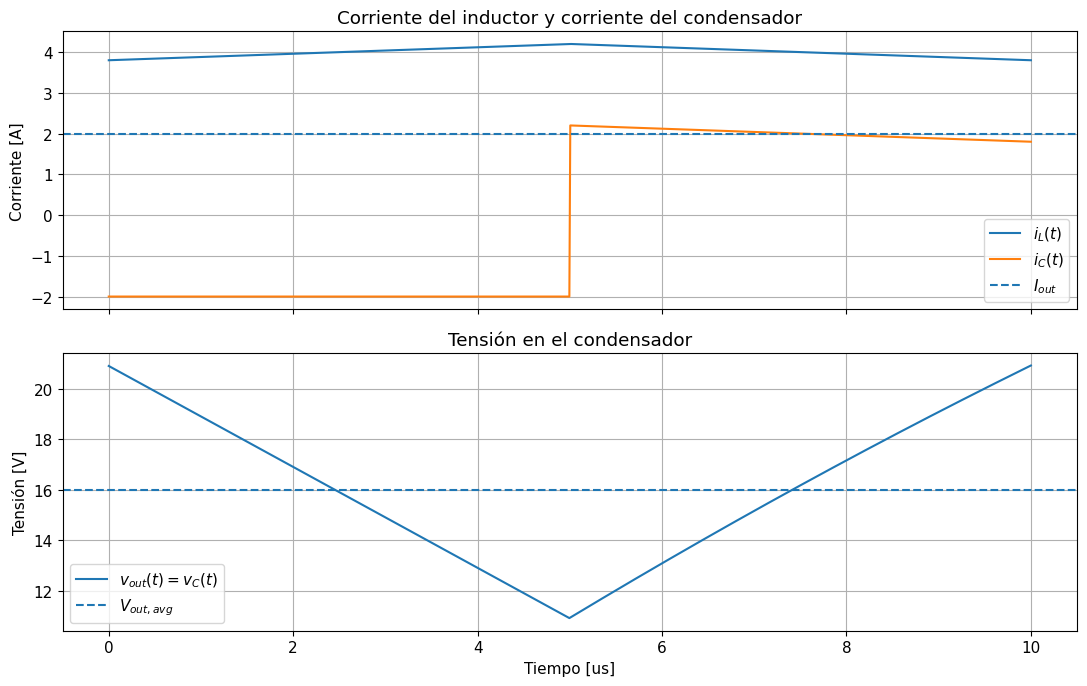

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Corrientes
ax[0].plot(t * 1e6, iL, label=r"$i_L(t)$")
ax[0].plot(t * 1e6, iC, label=r"$i_C(t)$")
ax[0].axhline(Iout_ideal, linestyle="--", label=r"$I_{out}$")

ax[0].set_ylabel("Corriente [A]")
ax[0].set_title("Corriente del inductor y corriente del condensador")
ax[0].grid(True)
ax[0].legend()

# Tensión
ax[1].plot(t * 1e6, vout_t, label=r"$v_{out}(t)=v_C(t)$")
ax[1].axhline(Vout_ideal, linestyle="--", label=r"$V_{out,avg}$")

ax[1].set_xlabel("Tiempo [us]")
ax[1].set_ylabel("Tensión [V]")
ax[1].set_title("Tensión en el condensador")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()


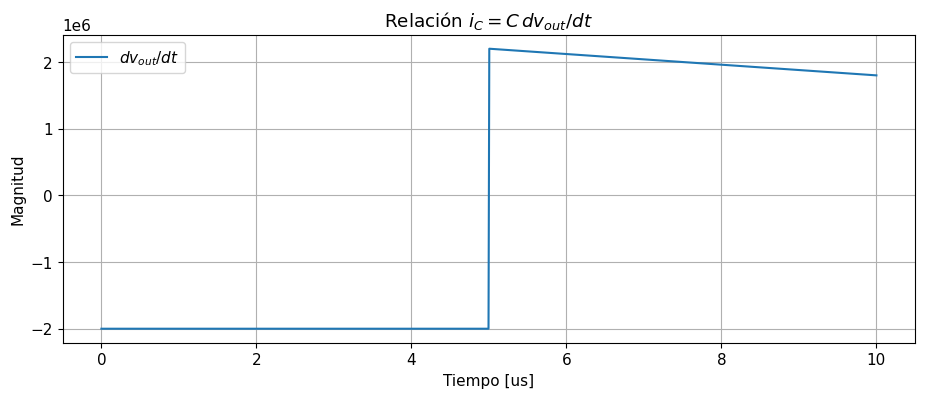

In [ ]:
# Verificación directa: iC = C * dvout/dt

dvout_dt = iC / C

plt.figure(figsize=(11, 4))
plt.plot(t * 1e6, dvout_dt, label=r"$dv_{out}/dt$")

plt.xlabel("Tiempo [us]")
plt.ylabel("Magnitud")
plt.title(r"Relación $i_C=C\,dv_{out}/dt$")
plt.grid(True)
plt.legend()

plt.show()


In [ ]:
# Simulación numérica del Boost ideal

t_stop    = 2e-3
dt        = 0.2e-6

t         = np.arange(0, t_stop + dt, dt)

iL        = np.zeros_like(t)
vout      = np.zeros_like(t)
gate      = np.zeros_like(t)

for k in range(len(t) - 1):
    # Estado del interruptor
    on      = (t[k] % Tsw) < Ton
    gate[k] = 1 if on else 0

    # Ecuación del inductor
    if on:
        di_dt = Vin / L
    else:
        di_dt = (Vin - vout[k]) / L

    # Ecuación del condensador
    if on:
        iC_k = -vout[k] / R
    else:
        iC_k = iL[k] - vout[k] / R

    # Integración Euler
    iL[k+1] = iL[k] + di_dt * dt
    vout[k+1] = vout[k] + (iC_k / C) * dt

gate[-1] = gate[-2]


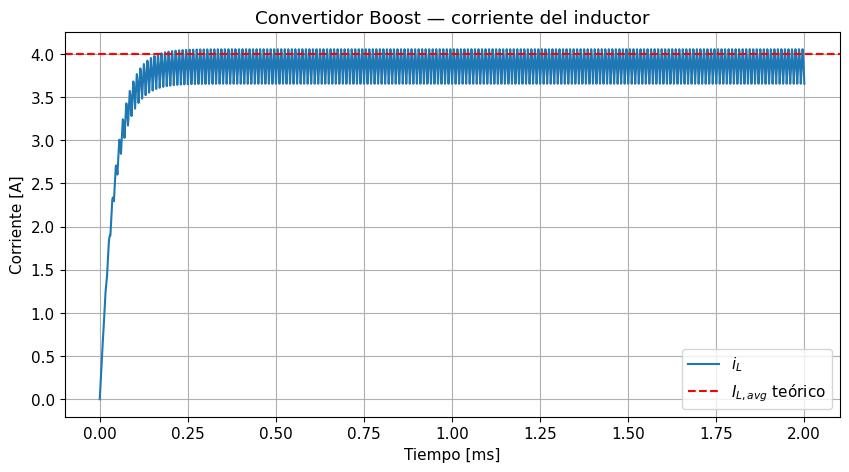

In [ ]:
plt.plot(t * 1e3, iL, label=r"$i_L$")
plt.axhline(I_L_avg, linestyle="--", label=r"$I_{L,avg}$ teórico",color='r')
plt.xlabel("Tiempo [ms]")
plt.ylabel("Corriente [A]")
plt.title("Convertidor Boost — corriente del inductor")
plt.grid(True)
plt.legend()
plt.show()


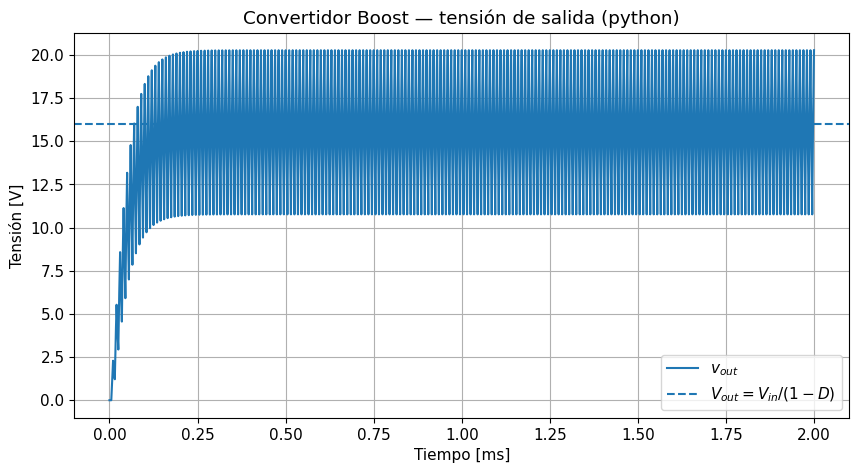

In [ ]:
plt.plot(t * 1e3, vout, label=r"$v_{out}$")
plt.axhline(Vout_ideal, linestyle="--", label=r"$V_{out}=V_{in}/(1-D)$")

plt.xlabel("Tiempo [ms]")
plt.ylabel("Tensión [V]")
plt.title("Convertidor Boost — tensión de salida (python)")
plt.grid(True)
plt.legend()
plt.show()


# **Simulación SPICE**

In [ ]:
# Instalar ngspice para linux dentro del entorno COLAB
!apt-get update -qq
!apt-get install -y ngspice


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Suggested packages:
  ngspice-doc
The following NEW packages will be installed:
  ngspice
0 upgraded, 1 newly installed, 0 to remove and 11 not upgraded.
Need to get 2,352 kB of archives.
After this operation, 7,972 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 ngspice amd64 36+ds-1ubuntu0.1 [2,352 kB]
Fetched 2,352 kB in 0s (12.5 MB/s)
Selecting previously unselected package ngspice.
(Reading database ... 118422 files and directories currently installed.)
Preparing to unpack .../ngspice_36+ds-1ubuntu0.1_amd64.deb ...
Unpacking ngspice (36+ds-1ubuntu0.1) ...
Setting up ngspice (36+ds-1ubuntu0.1) ...
Processing triggers for man-db (2.10.2-1) .

In [ ]:
# Comprobar la instalación solicitando la versión ngspice instalada
!ngspice -v


******
** ngspice-36 : Circuit level simulation program
** The U. C. Berkeley CAD Group
** Copyright 1985-1994, Regents of the University of California.
** Copyright 2001-2020, The ngspice team.
** Please get your ngspice manual from http://ngspice.sourceforge.net/docs.html
** Please file your bug-reports at http://ngspice.sourceforge.net/bugrep.html
** Creation Date: Mon Mar 11 21:44:53 UTC 2024
******


In [ ]:
netlist_boost = r"""
* CONVERTIDOR BOOST IDEAL

.title Boost converter - ideal switch

* Parámetros
.param Vinval = 8
.param Rval   = 8
.param Lval   = 100u
.param Cval   = 1u

.param Tsw    = 10u
.param Duty   = 0.5

* Fuente de entrada
V1 in 0 DC {Vinval}

* Señal de control
Vgate gate 0 PULSE(0 5 0 10n 10n {Duty*Tsw} {Tsw})

* Inductor
L1 in sw {Lval}

* Interruptor ideal: nodo sw -> GND cuando ON
S1 sw 0 gate 0 SWMOD

* Diodo: ánodo en sw, cátodo en out
D1 sw out DIDEAL

* Carga
R1 out 0 {Rval}

* Condensador de salida
C1 out 0 {Cval}

* Modelos
.model DIDEAL D(IS=1 N=1 RS=1m BV=100)
.model SWMOD SW(RON=1m ROFF=1Meg VT=2 VH=0.1)

* Análisis transitorio
.tran 0.1u 2m

.control
run
set filetype=ascii
wrdata boost_results.txt time v(out) i(L1)
.endc
.end
"""


In [ ]:
# Crear netlist
with open("boost.sp", "w") as f:
    f.write(netlist_boost)
print("Netlist creado: boost.sp")


Netlist creado: boost.sp


In [ ]:
# Ejecutar ngspice
result = subprocess.run(["ngspice", "-b", "boost.sp"], capture_output=True, text=True)
print(result.stdout)

if result.stderr:
    print("Mensajes:")
    print(result.stderr)

print("Código de salida:", result.returncode)

if result.returncode == 0:
    print("Simulación completada correctamente.")



No compatibility mode selected!


Circuit: Boost converter - ideal switch

Doing analysis at TEMP = 27.000000 and TNOM = 27.000000


Initial Transient Solution
--------------------------

Node                                   Voltage
----                                   -------
in                                           8
gate                                         0
sw                                           8
out                                    7.98101
l1#branch                             0.997634
vgate#branch                                 0
v1#branch                            -0.997634


No. of Data Rows : 28210

Mensajes:
Note: No ".plot", ".print", or ".fourier" lines; no simulations run

Código de salida: 1


In [ ]:
data = pd.read_csv("boost_results.txt", sep=r"\s+", engine="python", header=None)
data.head()


,0,1,2,3,4,5
0,0.000000e+00,0.000000e+00,0.000000e+00,7.981006,0.000000e+00,0.997634
1,1.000000e-10,1.000000e-10,1.000000e-10,7.981006,1.000000e-10,0.997634
2,2.000000e-10,2.000000e-10,2.000000e-10,7.981006,2.000000e-10,0.997634
3,4.000000e-10,4.000000e-10,4.000000e-10,7.981006,4.000000e-10,0.997634
4,8.000000e-10,8.000000e-10,8.000000e-10,7.981006,8.000000e-10,0.997634


In [ ]:
data.columns = ["time", "NADA1", "NADA2", "vout", "NADA3", "iL"]
data.tail()


,time,NADA1,NADA2,vout,NADA3,iL
28205,0.002,0.002,0.002,21.409216,0.002,4.598754
28206,0.002,0.002,0.002,21.599606,0.002,4.585201
28207,0.002,0.002,0.002,21.786275,0.002,4.571459
28208,0.002,0.002,0.002,21.969250,0.002,4.557532
28209,0.002,0.002,0.002,22.084171,0.002,4.548544


In [ ]:
# Comparación entre teoría y simulación
# Utilizamos solamente el último 20 % de la simulación
# para representar el régimen estacionario.

mask = data["time"] > 1.6e-3

vout_avg_sim = data.loc[mask, "vout"].mean()
iL_avg_sim = data.loc[mask, "iL"].mean()

iL_min_sim = data.loc[mask, "iL"].min()
iL_max_sim = data.loc[mask, "iL"].max()

vout_min_sim = data.loc[mask, "vout"].min()
vout_max_sim = data.loc[mask, "vout"].max()


In [ ]:
print("========== TEORÍA ==========")
print(f"Vout = {Vout_ideal:.4f} V")
print(f"Iout = {Iout_ideal:.4f} A")
print(f"IL medio = {I_L_avg:.4f} A")
print(f"Delta iL = {delta_iL:.4f} A")

print("\n======= NGSPICE =======")
print(f"Vout medio = {vout_avg_sim:.4f} V")
print(f"IL medio   = {iL_avg_sim:.4f} A")
print(f"IL mínimo  = {iL_min_sim:.4f} A")
print(f"IL máximo  = {iL_max_sim:.4f} A")
print(f"Delta iL   = " f"{iL_max_sim-iL_min_sim:.4f} A")
print(f"Vout min   = {vout_min_sim:.4f} V")
print(f"Vout max   = {vout_max_sim:.4f} V")


========== TEORÍA ==========
Vout = 16.0000 V
Iout = 2.0000 A
IL medio = 4.0000 A
Delta iL = 0.4000 A

======= NGSPICE =======
Vout medio = 15.1589 V
IL medio   = 4.7685 A
IL mínimo  = 4.5480 A
IL máximo  = 4.9486 A
Delta iL   = 0.4007 A
Vout min   = 8.0830 V
Vout max   = 22.0914 V


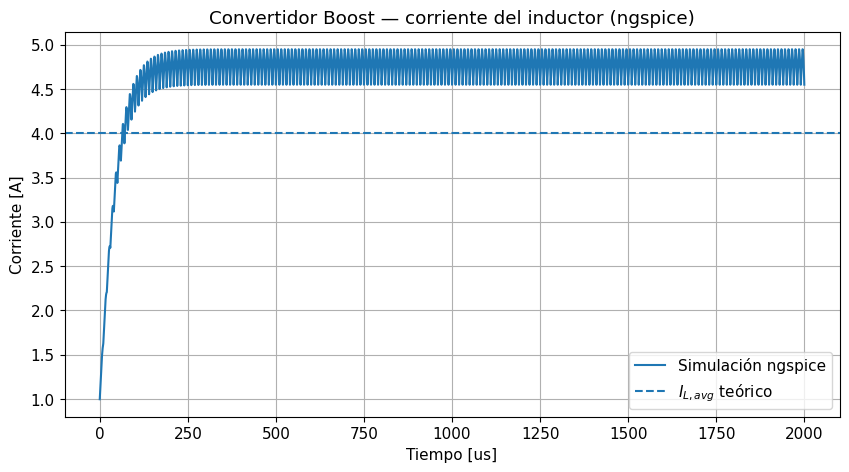

In [ ]:
plt.plot(data["time"] * 1e6, data["iL"], label="Simulación ngspice")
plt.axhline(I_L_avg, linestyle="--", label=r"$I_{L,avg}$ teórico")
plt.xlabel("Tiempo [us]")
plt.ylabel("Corriente [A]")
plt.title("Convertidor Boost — corriente del inductor (ngspice)")
plt.grid(True)
plt.legend()
plt.show()


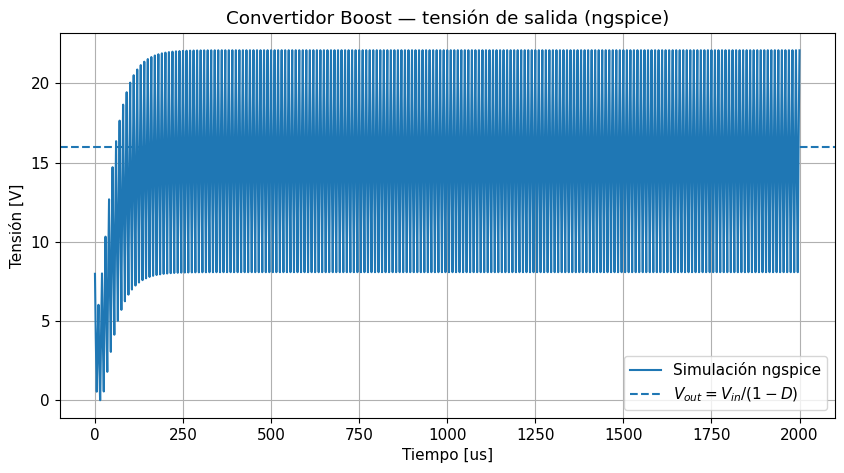

In [ ]:
plt.plot(data["time"] * 1e6, data["vout"], label="Simulación ngspice")
plt.axhline(Vout_ideal, linestyle="--", label=r"$V_{out}=V_{in}/(1-D)$")
plt.xlabel("Tiempo [us]")
plt.ylabel("Tensión [V]")
plt.title("Convertidor Boost — tensión de salida (ngspice)")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# Construcción del modelo triangular teórico de iL

# Elegimos un periodo situado en régimen estacionario
T0 = 1.8e-3
T1 = T0 + Tsw

mask_period = ((t >= T0) & (t <= T1))

t_period = t[mask_period]
i_period = iL[mask_period]


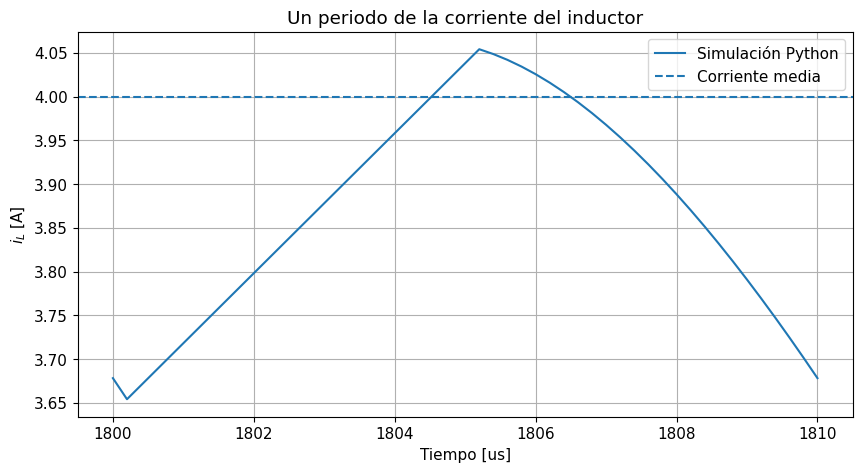

In [ ]:
plt.plot(t_period * 1e6, i_period, label="Simulación Python")

plt.axhline(I_L_avg, linestyle="--", label="Corriente media")

plt.xlabel("Tiempo [us]")
plt.ylabel(r"$i_L$ [A]")
plt.title("Un periodo de la corriente del inductor")
plt.grid(True)
plt.legend()

plt.show()
